<p>
<h1><b><center></center></b></h1>
<center><img src="https://drive.google.com/uc?id=1UJc1ci41G6ahJ7ProKvunUOIBcTXZ6ZG" align="center" width="550"></center>
</p>
<h1><b><center>Relatividad y Gravitación</center></b></h1>
<h2><b><center>Prof. Jorge I. Zuluaga</center></b></h1>
<h2><b><center>Problem Set 13</center></b><h2>
<h3><b><center>Ondas Gravitacionales</center></b><h3>


**NOTA**: Al inicio de la solución entregada debe incluir una relación de los puntos y los literales que resolvió completamente.

> Jhoan Londoño Restrepo
>
> Se resolvió la 2da parte del Problem Set

A continuación se presentan un conjunto de ejercicios o problemas para resolver usando la teoría vista en las últimas lecciones del curso. Resuelva los ejercicios *a mano* y suba una versión digitalizada en el espacio del ítem respectivo en Google Classroom.

**NOTA**: Los ejercicios marcados como **[Numérico]** deben resolverse exclusivamente usando las herramientas numéricas vistas en el curso, incluso si tienen una solución que puede obtenerse de forma enteramente analítica. El objetivo es que se aprendan a utilizar esas herramientas.

### Parte 1

1. **El tensor de polarización**. Para una onda gravitacional plana que se propaga en dirección de z, $h_{\mu \nu}=a_{\mu \nu} \cos \left(\omega t-kz+\varphi\right)$, pruebe que la condición del gauge armónico implica que el tensor de polarización tiene la estructura:

  $$
  a_{\mu \nu}=\left(\begin{array}{cccc}
a_{t t} & a_{t x} & a_{t y} & -\left(a_{t t}+a_{z z}\right) / 2 \\
a_{t x} & -a_{y y} & a_{x y} & -a_{t x} \\
a_{t y} & a_{x y} & a_{y y} & -a_{t y} \\
-\left(a_{t t}+a_{z z}\right) / 2 & -a_{t x} & -a_{t y} & a_{z z}
\end{array}\right)
  $$
  
  Realice el procedimiento paso a paso.

### Parte 2

In [ ]:
!pip install -Uq einsteinpy

In [ ]:
import einsteinpy.symbolic as es

import sympy as sp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

from scipy.integrate import quad
from ipywidgets import interact, FloatSlider, fixed

2. **El gusano gravitacional**. Use una herramienta de animación para construir una animación en tres dimensiones de una onda gravitacional, similar a la que aparece en la Diapositiva 45 de la presentación [RG 2024-2 - Clase 29 - GRAV: Ondas Gravitacionales: Detección](https://docs.google.com/presentation/d/1Pe1jc4hB7hv-N9rGnodOtWIZnge1K7ISrrtjEPX0beo/edit?usp=sharing).

In [ ]:
# Deformación métrica para un punto situado en cualquier dirección
def strain_onda_gravitacional(ap,ax,k,u,phi,x,y,z):
  r = (x**2 + y**2 + z**2)**0.5

  # Vector unitario en la dirección del punto
  nx = x/r
  ny = y/r
  nz = z/r

  # Distancia a partir de la métrica
  def integrando(zp):
    wave = np.cos(k*u + phi - k*nz*zp)
    h11 = ap*wave
    h12 = ax*wave
    h22 = -ap*wave
    I = h11*nx**2 + 2*h12*nx*ny + h22*ny**2
    return I

  # Cálculo del strain
  strain = 0.5*quad(integrando,0,r)[0]/r
  return strain

In [ ]:
R0 = 1      # Unidades luz
c = 1
deg = np.pi/180

# Propiedades de las partículas
omega = 1
P = 2*np.pi/omega     # Periodo
k = omega/c           # Número de onda
phi = 0               # Fase inicial

# Deformación métrica
ap = 1        # Amplitud axial
ax = 0        # Amplitud transversal

# Dirección en la que está la partícula
thetas = np.arange(0, 360*deg, 10*deg)
nxs = np.cos(thetas)
nys = np.sin(thetas)

# Posiciones iniciales de las partículas (Cilindro a deformar)
xos = R0*np.cos(thetas)
yos = R0*np.sin(thetas)
zos = np.linspace(-4, 4, len(xos))

# Simulación de deformación en un intervalo de tiempo
ts = np.linspace(0,3*P,100)
df = pd.DataFrame()

for t in ts:
  # Deformación para todo el cilindro
  for z in zos:
    u = c*t - z

    h11 = ap*np.cos(k*u + phi - k*z)
    h12 = ax*np.cos(k*u + phi - k*z)
    h22 = -ap*np.cos(k*u + phi - k*z)

    # Deformación
    Rs = R0*(1 + 0.5*(h11*nxs*nxs + 2*h12*nxs*nys + h22*nys*nys))
    xs = Rs*nxs
    ys = Rs*nys

    df = pd.concat([df,pd.DataFrame({'x':xs,'y':ys,'z':z,'t':t})])

In [ ]:
fig = px.scatter_3d(
    df,
    x='x',
    y='y',
    z='z',
    width=500,
    height=500,
    animation_frame='t',
)
fig.update_traces(marker=dict(
    size=3,
    color='blue'
))
fig.update_layout(
    xaxis=dict(range=[-2.5*R0, 2.5*R0]),
    yaxis=dict(scaleratio=1,fixedrange=True,scaleanchor='x')
)
fig.layout.updatemenus[0].buttons[0].args[1]['frame']['duration'] = 50      # milisegundos por fotograma
fig.layout.updatemenus[0].buttons[0].args[1]['transition']['duration'] = 0  # sin transición
fig.show()

Output hidden; open in https://colab.research.google.com to view.

**Graficar circunferencias y unir con fill between**

3. **Simulación de la señal de una onda gravitacional**. Una onda gravitacional plana es detectada por un interferometro de Michelson que tiene un camino óptico en cada brazo de longitud $L_0 = 1200 km$ (este es el caso del interferometro LIGO). La onda tiene una frecuencia de 100 mHz y una polarización $a_+ = 6\times 10^{-22}$ y $a_\times = 2\times 10^{-22}$.

  1. Suponga que por pura casualidad la onda gravitacional proviene desde arriba y lleva al detector de modo que los brazos están sobre los ejes naturales de la onda. Haga un gráfico de la señal percibida por el detector de luz $\delta I/I_0$ como función del tiempo por 10 períodos de la onda. ¿Cómo cambia la señal (si cambia) si en lugar de llegar desde arriba, la señal llega desde abajo?.

Si la onda gravitacional proviene desde arriba, el eje $x$ de la onda coincide con el eje $x$ del detector, por lo que las componentes de los vectores unitarios de las direcciones de los brazos del detector respecto de los ejes de la onda coinciden con los del detector:

$$
\hat{n}_x = \hat{n}'_x : (1,0,0) \\
\hat{n}_y = \hat{n}'_y : (0,1,0)
$$

Bajo estas condiciones, la deformación de la distancia en los brazos está dada por:

$$
\delta L_x = \frac{1}{2} L_0 h_{xx} \hat{n}_x \cdot \hat{n}_x = \frac{1}{2} L_0  a_+ \cos (ku + \phi) \\
\delta L_y = \frac{1}{2} L_0 h_{yy} \hat{n}_y \cdot \hat{n}_y = -\frac{1}{2} L_0 a_+ \cos (ku + \phi)
$$

La diferencia de longitud entre ambos brazos es entonces:

$$\Delta L = \delta L_x - \delta L_y = L_0 a_+ \cos (ku + \phi)$$

Luego, la ecuación de la señal percibida por el interferómetro está dada por:

$$
\frac{\delta I}{I_0} = \frac{1}{2} \left[ 1 - \cos \left( 2\pi \frac{\Delta L}{\lambda} \right) \right]
$$

Siendo $\lambda$ la longitud de onda del detector.

Cuando $\Delta L \ll \lambda$, como es el caso de LIGO, la ecuación anterior se transforma en:

$$
\frac{\delta I}{I_0} = \left( \pi \frac{\Delta L}{\lambda} \right)^2
$$

\
Si por el contrario la onda proviene desde abajo, el eje $y$ del detector de alinea con el eje $-y$ de la onda:

$$
\hat{n}_x = \hat{n}'_x : (1,0,0) \\
\hat{n}_y = -\hat{n}'_y : (0,-1,0)
$$

Pero se puede ver que diferencia de distancia no cambia, por lo que la señal no cambia tampoco.

In [ ]:
c = 299792458   # [m/s] Velocidad de la luz

L0 = 1200e3       # [m] Longitud de los brazos del detector
lambda_ = 6.0e-7  # [m] Longitud de onda láser de LIGO

# Propiedades de la onda
f = 100e-3      # [Hz] Frecuencia de la onda
P = 1/f         # [s] Periodo de la onda
omega = 2*np.pi*f
k = omega/c     # Número de onda
phi = 0         # Fase inicial

# Deformación métrica
ap = 6e-22      # Amplitud axial positiva
ax = 2e-22      # Amplitud trasversal negativa

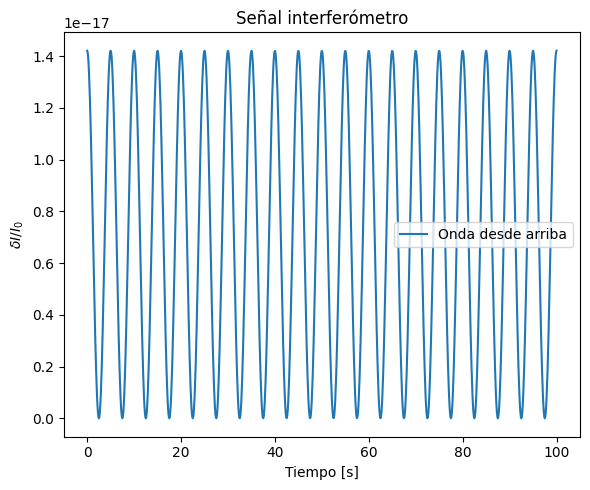

In [ ]:
''' ----------------------- Punto 1 ----------------------- '''

ts = np.linspace(0, 10*P, 1000)     # Simulación en 10 periodos

# Deformaciones métricas
hxx = ap*np.cos(omega*ts + phi)
hxy = ax*np.cos(omega*ts + phi)
hyy = -hxx

# Deformación de la distancia
DL_arriba = L0*hxx

# dI_I0_arriba = 0.5*(1 - np.cos(2*np.pi*DL/lambda_))
dI_I0_arriba = (np.pi*DL_arriba/lambda_)**2

fig = plt.figure(figsize=(6, 5))
plt.title('Señal interferómetro')
plt.plot(ts, dI_I0_arriba, label='Onda desde arriba')
plt.xlabel('Tiempo [s]')
plt.ylabel(r'$\delta I / I_0$')
plt.legend()
plt.grid(False)
fig.tight_layout()

  2. Calcula la misma señal pero suponiendo ahora que llega en un ángulo inclinado 60 grados respecto a la vertical (ángulo cenital $z = 60^\circ$ o elevación $h=30^\circ$), pero manteniendo el hecho que uno de los brazos coincide con el eje $y'$ de la onda. ¿Cómo cambia la señal?

Para una onda que incide inclinada con ángulo cenital $θ$, el efecto sobre el detector se reduce según la función de patrón (antenna pattern) para la polarización “+”:

$$
F_{+}(\theta, \psi)
= \tfrac{1}{2}\,\bigl(1 + \cos^2 \theta\bigr)\,\cos\bigl(2\psi\bigr)
$$

Donde:

* $θ$ es el ángulo entre la dirección de propagación de la onda y la vertical del detector.

* $ψ$ es el ángulo de giro de los ejes del detector respecto a los ejes naturales de la onda.

Dado que uno de los ejes se alinea con $y'$ (el eje natural de la polarización de la onda), elegimos $ψ=0$.

> **Nota:** Esta teoría fue consultada con chatGPT OpenAI versión o1.

La diferencia de longitud entre ambos brazos, que está dada por:

$$\Delta L = \delta L_x - \delta L_y = L_0 a_+ \cos (ku + \phi)$$

Con esta reducción pasa a ser:

$$\Delta L = L_0 F_+ a_+ \cos (ku + \phi)$$



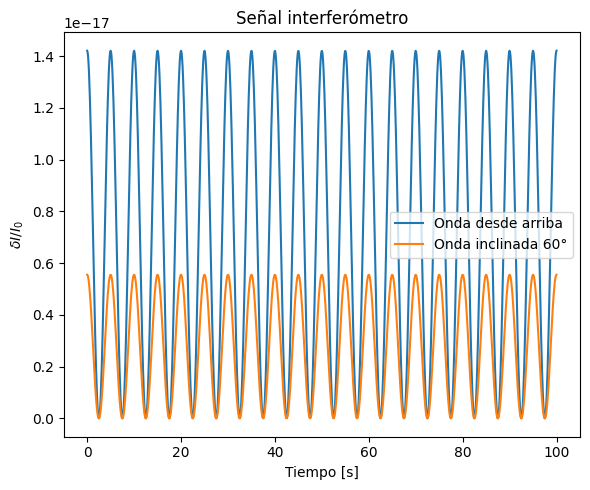

In [ ]:
''' ----------------------- Punto 2 ----------------------- '''

i = np.radians(60)      # Inclinación de entrada
Fp = 0.5*(1 + np.cos(i)**2)

hxx_ = hxx*Fp
DL_ = L0*Fp*hxx

dI_I0_Fp = (np.pi*DL_/lambda_)**2

fig = plt.figure(figsize=(6, 5))
plt.title('Señal interferómetro')
plt.plot(ts, dI_I0_arriba, label='Onda desde arriba')
plt.plot(ts, dI_I0_Fp, label='Onda inclinada 60°')
plt.xlabel('Tiempo [s]')
plt.ylabel(r'$\delta I / I_0$')
plt.legend()
plt.grid(False)
fig.tight_layout()

  3. Si se supone que la señal llega desde una dirección arbitraria en un azimuth $A$ y en un ángulo cenital $z$, respecto de los ejes de la onda gravitacional la posición de los extremos de los brazos del detector se puede mostrar es:

    \begin{aligned}
& \vec{L}_x:L_0(\cos A,-\sin A \cos z, \sin A \cos z) \\
& \vec{L}_y:L_0(\sin A, \cos A \cos z,-\cos A \sin z)
\end{aligned}

    Haga una rutina que calcule la señal (con las mismas condiciones que 1) para un azimut y angulo cenital arbitrario. Haga un interactivo con `IPywidgets` para mostrar cómo varía la señal cuando cambia $A$ y $z$.

In [ ]:
''' ----------------------- Punto 3 ----------------------- '''

# Direcciones de los brazos del detector respecto de los ejes de la onda
nx = lambda A,z: np.array([np.cos(A), -np.sin(A)*np.cos(z), np.sin(A)*np.cos(z)])
ny = lambda A,z: np.array([np.sin(A), np.cos(A)*np.cos(z), -np.cos(A)*np.sin(z)])

# Perturbación métrica
def hij(i,j,u):
  if i==3: return 0
  if i != j: h = ax*np.cos(k*u + phi)
  elif i==1: h = ap*np.cos(k*u + phi)
  elif i==2: h = -ap*np.cos(k*u + phi)
  return h

# Cambio en la distancia en dirección al vector n_i: Deformación de distancia
def deltaL(t,n):
  def integrando(s):
    u = c*t-n[2]*s      # Velocidad relativa
    Int = hij(1,1,u)*n[0]**2 + 2*hij(1,2,u)*n[0]*n[1] + hij(2,2,u)*n[1]**2
    return Int
  dL = 0.5*quad(integrando,0,L0)[0]
  return dL

# Cambio en la intensidad: señal percibida por el interferómetro
def dI_I0(t,nx,ny):
  # Deformación en los brazos del detector
  dL_x = deltaL(t,nx)
  dL_y = deltaL(t,ny)
  DL = dL_y - dL_x
  # Cambio en la señal
  # deltaI_I0 = 0.5*(1- np.cos(2*np.pi*DL/lambda_))
  deltaI_I0 = (np.pi*DL/lambda_)**2
  return deltaI_I0

In [ ]:
'''
  Grafica la señal dI_I0(t) para t en un rango de 10 periodos
  Se parametriza A en [0..360], z en [0..180] (grados).
'''
@interact(A_deg=(0,360,5), z_deg=(0,360,5))
def señal(A_deg=0.0, z_deg=0.0):
  A = np.radians(A_deg)
  z = np.radians(z_deg)

  ts = np.linspace(0, 3*P, 1000)
  dI_I0s = [dI_I0(t, nx(A, z), ny(A, z)) for t in ts]

  fig = plt.figure(figsize=(6, 5))
  plt.title(f'Señal interferómetro\nA={A_deg:.1f}°, z={z_deg:.1f}°')
  plt.plot(ts, dI_I0s)
  plt.xlabel('Tiempo [s]')
  plt.ylabel(r'$\delta I / I_0$')
  plt.grid(False)
  plt.show()
  fig.tight_layout()

interactive(children=(IntSlider(value=0, description='A_deg', max=360, step=5), IntSlider(value=0, description…

**NOTA**: Algunas correcciones al enunciado pueden ser publicadas con posterioridad a la formulación del problem set. Es importante que este pendiente de la última versión de este documento antes de enviar la solución.